# NBA MVP Predictor

Rhys Pulling

This project is aimed at analyzing various data from the NBA, with the end goal being trying to create a model that can help predict the MVP of a season based on various factors. This notebook focuses on the feature selection, data preprocessing, training, and testing of the model. If you are interested in the data, you can check out the "nba_eda" notebook in the same repository. 

In [ ]:
# !pip install pandas numpy matplotlib seaborn scikit-learn plotly.express nbformat nba_api statsmodels ipywidgets xgboost shap

In [52]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
from nba_api.stats.endpoints import leaguedashplayerstats
from nba_api.stats.endpoints import leaguedashteamstats

# Regression/Stats
from scipy import stats
import statsmodels.api as sm1
import statsmodels.formula.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Visualizations
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Feature Importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import shap
from xgboost import XGBClassifier, plot_importance
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

## Data Collection

In [3]:
def get_player_stats(season):
    """
    Fetch player stats for a given player ID and season.
    """
    stats = leaguedashplayerstats.LeagueDashPlayerStats(season=season, season_type_all_star='Regular Season')
    df = stats.get_data_frames()[0]
    df["SEASON"] = season
    return df

def get_team_stats(season):
    """
    Fetch team stats for a given season.
    """
    teams = leaguedashteamstats.LeagueDashTeamStats(season=season, season_type_all_star='Regular Season')
    df = teams.get_data_frames()[0]
    df['SEASON'] = season
    return df[['TEAM_ID', 'TEAM_NAME', 'W', 'L', 'W_PCT', 'SEASON']]

In [4]:
all_seasons = []
for year in range(2000, 2024):
    season = f"{year}-{str(year + 1)[-2:]}"
    try:
        df_season = get_player_stats(season)
        df_team = get_team_stats(season)  
        df_season = df_season.merge(df_team, on=['SEASON', 'TEAM_ID'], how='left', suffixes=('', '_team'))
        all_seasons.append(df_season)
        print(f"Fetched data for {season}")
    except Exception as e:
        print(f"Error fetching data for {season}: {e}")
    time.sleep(1)  # To avoid hitting API rate limits

df_nba = pd.concat(all_seasons, ignore_index=True)

Fetched data for 2000-01
Fetched data for 2001-02
Fetched data for 2002-03
Fetched data for 2003-04
Fetched data for 2004-05
Fetched data for 2005-06
Fetched data for 2006-07
Fetched data for 2007-08
Fetched data for 2008-09
Fetched data for 2009-10
Fetched data for 2010-11
Fetched data for 2011-12
Fetched data for 2012-13
Fetched data for 2013-14
Fetched data for 2014-15
Fetched data for 2015-16
Fetched data for 2016-17
Fetched data for 2017-18
Fetched data for 2018-19
Fetched data for 2019-20
Fetched data for 2020-21
Fetched data for 2021-22
Fetched data for 2022-23
Fetched data for 2023-24


In [5]:
mvp_dict = {
    '2000-01': 'Allen Iverson',
    '2001-02': 'Tim Duncan',
    '2002-03': 'Tim Duncan',
    '2003-04': 'Kevin Garnett',
    '2004-05': 'Steve Nash',
    '2005-06': 'Steve Nash',
    '2006-07': 'Dirk Nowitzki',
    '2007-08': 'Kobe Bryant',
    '2008-09': 'LeBron James',
    '2009-10': 'LeBron James',
    '2010-11': 'Derrick Rose',
    '2011-12': 'LeBron James',
    '2012-13': 'LeBron James',
    '2013-14': 'Kevin Durant',
    '2014-15': 'Stephen Curry',
    '2015-16': 'Stephen Curry',
    '2016-17': 'Russell Westbrook',
    '2017-18': 'James Harden',
    '2018-19': 'Giannis Antetokounmpo',
    '2019-20': 'Giannis Antetokounmpo',
    '2020-21': 'Nikola Jokic',
    '2021-22': 'Nikola Jokic',
    '2022-23': 'Joel Embiid',
    '2023-24': 'Nikola Jokic'
}

def normalize_name(name):
    return name.lower().replace('.', '').replace(' ', '')

normalized_mvp_dict = {season: normalize_name(name) for season, name in mvp_dict.items()}

def assign_mvp_flag(row):
    season = row['SEASON']
    player = normalize_name(row['PLAYER_NAME'])
    return 1 if normalized_mvp_dict.get(season, '') == player else 0

df_nba['IS_MVP'] = df_nba.apply(assign_mvp_flag, axis=1)

In [7]:
drop_columns = ['NICKNAME', 'TEAM_ABBREVIATION', 'TEAM_CITY', 'TEAM_ID', 'PLAYER_ID', 'WNBA_FANTASY_PTS', 'WNBA_FANTASY_PTS_RANK']
df_nba.drop(columns=drop_columns, inplace=True, errors='ignore')
df_nba.rename(columns={'PLAYER_NAME': 'PLAYER', 'TEAM_NAME': 'TEAM'}, inplace=True)
df_nba.head()

,PLAYER,AGE,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,...,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,SEASON,TEAM,W_team,L_team,W_PCT_team,IS_MVP
0,A.C. Green,37.0,82,50,32,0.610,1411.818333,144,324,0.444,...,95,218,126,26,2000-01,Miami Heat,50,32,0.610,0
1,A.J. Guyton,23.0,33,6,27,0.182,628.538333,78,192,0.406,...,378,317,224,26,2000-01,Chicago Bulls,15,67,0.183,0
2,Aaron McKie,28.0,76,51,25,0.671,2390.726667,338,714,0.473,...,20,84,77,4,2000-01,Philadelphia 76ers,56,26,0.683,0
3,Aaron Williams,29.0,82,26,56,0.317,2334.001667,297,650,0.457,...,434,77,53,26,2000-01,New Jersey Nets,26,56,0.317,0
4,Adam Keefe,31.0,67,14,53,0.209,841.858333,64,159,0.403,...,385,274,224,26,2000-01,Golden State Warriors,17,65,0.207,0


## Multicollinearity

It is useful to check for multicollinearity in the variables, even if we aren't doing regression. We can use variance inflation factor to see if any exists.

In [22]:
numerical_columns = df_nba.select_dtypes(include=[np.number]).columns.tolist()
X = df_nba.drop(columns=[col for col in df_nba.columns if col not in numerical_columns])
vif_table = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif_table = vif_table[vif_table["Feature"] != "const"]
vif_table = vif_table.set_index("Feature")
vif_table.sort_values(by="VIF", ascending=False, inplace=True)
vif_table

c:\Users\chees\Projects\NBA_Analysis\nba-analysis\nba_env\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF
Feature,
GP,inf
W,inf
L,inf
FGM,inf
FG3M,inf
...,...
DD2,13.952162
PLUS_MINUS,8.030872
PFD,5.867554


We are getting infinite VIF for some of the variables. This means that there are features that are perfectly collinear, which if we look at the variables this makes sense. Games Played, Wins, and Losses all would have different factors that could easily correlate to them. The easiest way to reduce MC is to remove variables with high VIF. We can try removing all the RANK variables, as well as GP.

In [30]:
# drop_columns = ["GP", "FGA_RANK", "FTA_RANK", "FG3A_RANK", "FG3M_RANK", "FTM_RANK", "OREB_RANK", "DREB_RANK", "REB_RANK", "AST_RANK", "STL_RANK", "BLK_RANK", "TOV_RANK", "PF_RANK", "PTS_RANK"]
X.drop(columns=[col for col in X.columns if "RANK" in col], inplace=True, errors='ignore')
X.drop(columns=["GP", "NBA_FANTASY_PTS", "REB"], inplace=True, errors='ignore')
vif_table = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif_table = vif_table[vif_table["Feature"] != "const"]
vif_table = vif_table.set_index("Feature")
vif_table.sort_values(by="VIF", ascending=False, inplace=True)
vif_table

,VIF
Feature,
W_PCT_team,480.675036
W_team,412.142957
FGA,284.339885
FGM,233.789738
FTA,137.049835
FTM,118.818992
MIN,85.872218
AGE,45.159516
TOV,36.728994


It looks like the RANK variables, NBA_FANTASY_PTS, and the Rebounding variables are all causes for the infinite VIF. In order to reduce this, we had to remove ALL "RANK" variables, NBA_FANTASY_PTS, and REBOUNDS and it still persisted. While non-linear methods aren't as affected by multicollinearity, if we want interpretable results then we want to reduce MC as much as we can. The question ends up being whether or not it is worth losing these variables. For the ones above, a players RANK relative to others may actually be a great indicator of whether or not they end up getting MVP. Their NBA_FANTASY_PTS are directly calculated from their play statistics, so this variable may not be required, and the same thing could be argued for REB. 

For now, it may be useful to use all the features when going through feature extraction.

## Data Preprocessing

Before we move on to feature extraction and the model, we want to do some preprocessing to set the data up to be passed into the model. This involves feature scaling, one-hot-encoding, and splitting the data into train and test splits. We want to standardize the features after the split in order to avoid any data leakage. 

In [37]:
# one-hot-encode categorical variables
X = X.drop(columns=['IS_MVP'], errors='ignore')
X = pd.get_dummies(X, drop_first=True)
y = df_nba['IS_MVP']

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Feature Extraction

An important step is to extract the best features for our models. This may change depending on the model, but it is unrealistic to try out every combination for every method. This will hopefully give us a better understanding of the variables we would like to use. 

### Random Forest Regressor

Random forest regressor is a non-linear method that creates an ensemble of decision trees in order to find the best way to predict the response. It has a nice feature that tells us how important it believes the variables are. While this isn't a 1-1 ratio for all methods, it is interesting to look at.

In [43]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y=y)

# Get feature importance
feature_importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
feature_importance_df.drop(index=feature_importance_df[feature_importance_df['Importance'] < 0.01].index, inplace=True)
display(feature_importance_df)

,Feature,Importance
54,PTS_RANK,0.070841
35,FGM_RANK,0.067069
26,PLUS_MINUS,0.066743
27,NBA_FANTASY_PTS,0.064664
55,PLUS_MINUS_RANK,0.059540
33,W_PCT_RANK,0.053885
31,W_RANK,0.052245
32,L_RANK,0.038552
18,AST,0.030397
56,NBA_FANTASY_PTS_RANK,0.023632


We get to see that the team doesn't appear to be useful at all in predicting the MVP. This would make sense, as the team a player is on shouldn't matter in the long run. It also appeared to determine that a players RANK in a stat is fairly useful in the prediction. For our final model, we will most likely want to drop out TEAM and keep RANK variables. 

C:\Users\chees\AppData\Local\Temp\ipykernel_2148\1696211809.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


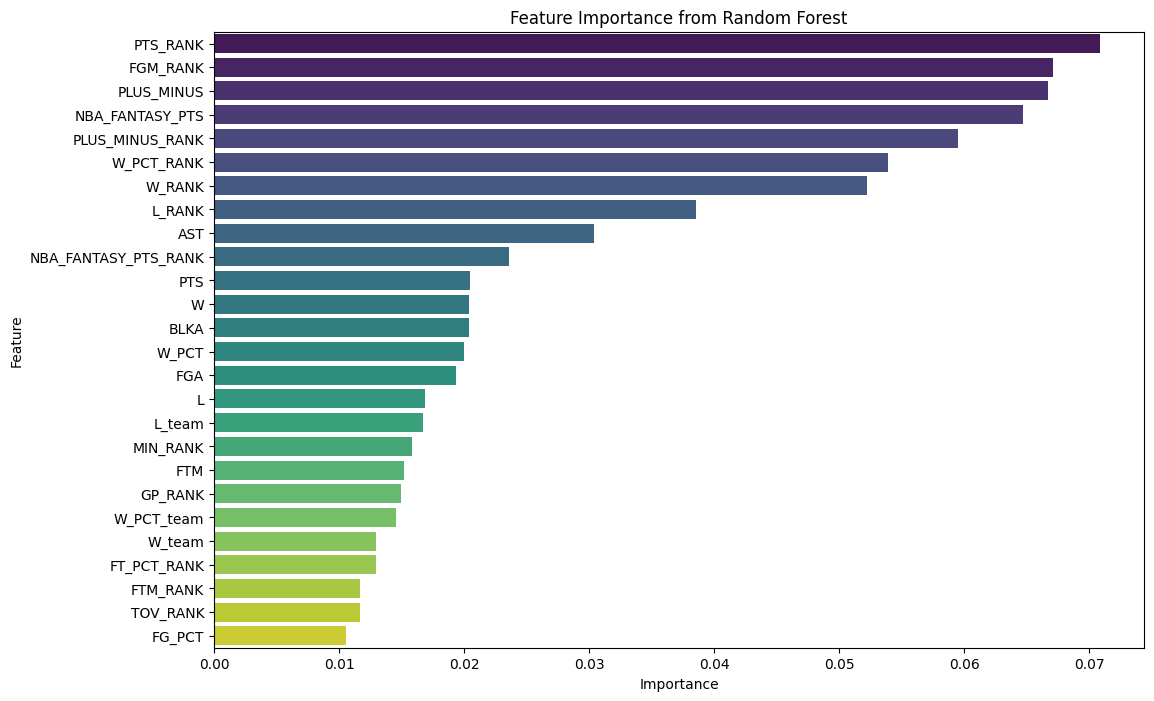

In [44]:
# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Logistic Regression w/ Lasso

Lasso is a regularization technique that prevents overfitting by penalizing the coefficients. Since it uses an L1-norm, it can reduce the features all the way to zero. While it is a linear method, it is useful to look and see what features it decides are unimportant in the equation. 

<Axes: title={'center': 'L1 Logistic Coefficients'}>

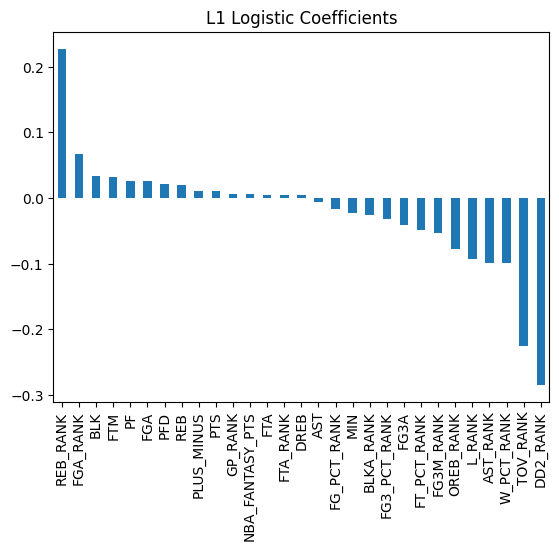

In [53]:
clf = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42)

clf.fit(X_train, y_train)
coef = clf.coef_[0]
importance = pd.Series(coef, index=X.columns)
importance[importance != 0].sort_values(ascending=False).plot(kind='bar', title='L1 Logistic Coefficients')

We get a similar answer to RFR, with TEAM not being an important factor. We also see that the "PLAYER" name also isn't relevant, which is good to know as it should be how the player plays and not who they are that gets them the award.

### XGBoost Classifier

c:\Users\chees\Projects\NBA_Analysis\nba-analysis\nba_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:34:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Axes: title={'center': 'XGBoost Feature Importance (gain)'}, xlabel='Importance score', ylabel='Features'>

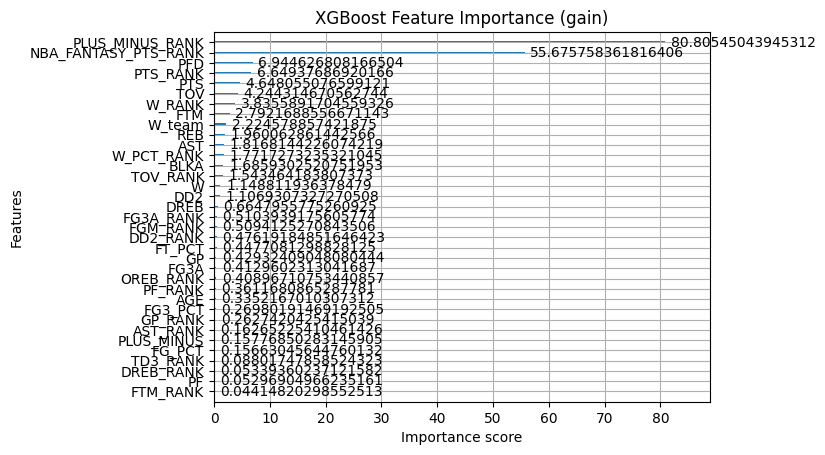

In [ ]:
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train, y_train)

# Built-in feature importance plot
plot_importance(xgb_clf, importance_type='gain', title='XGBoost Feature Importance (gain)')

We have similar answers for the XGBoost classifier feature importance. One interesting aspect is this is the first model to find TOV at least somewhat important, as it didn't even show up in either of the other methods we have tried. 

### SHapley Values

SHapley values is a method designed to tell us how much each feature "pushes" the prediction towards MVP or not. It gives us a local and global interpretation of the data

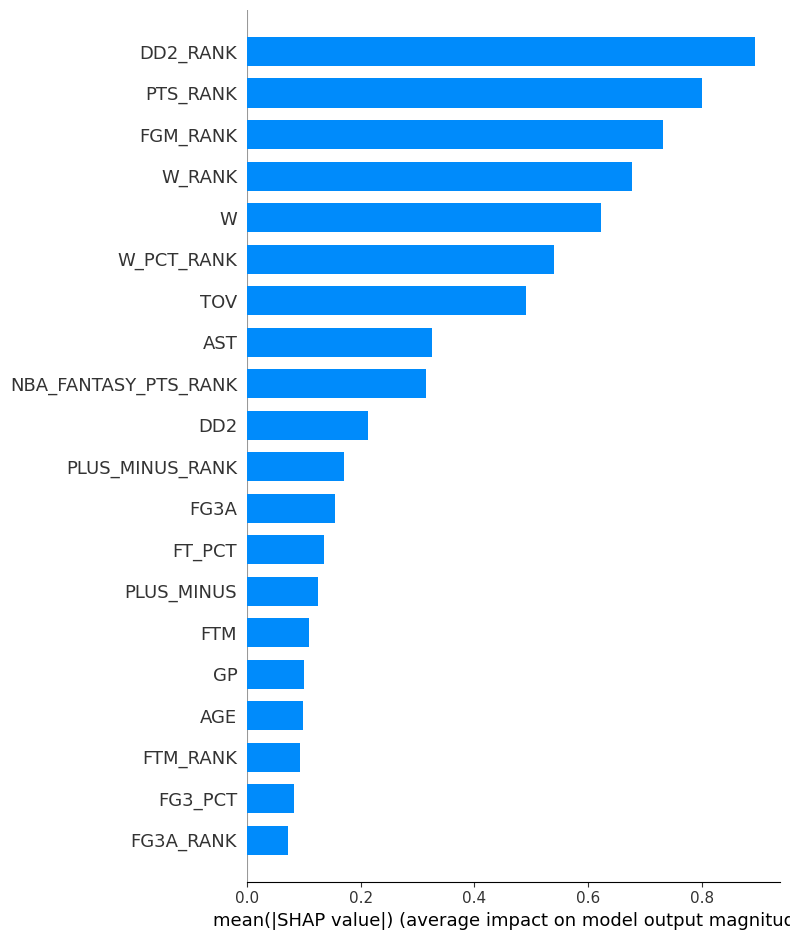

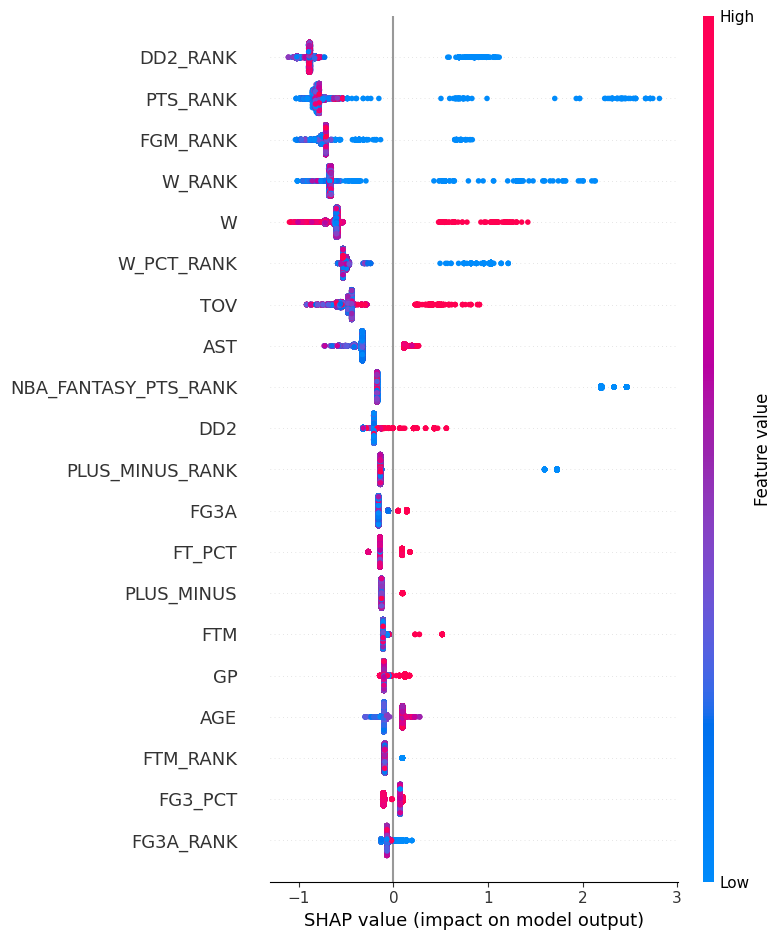

In [51]:
# Use tree explainer for tree-based models
explainer = shap.TreeExplainer(xgb_clf)  # or clf for RandomForest
shap_values = explainer.shap_values(X)

# Global summary
shap.summary_plot(shap_values, X, plot_type="bar")

# Detailed summary per feature
shap.summary_plot(shap_values, X)

### Permutation Feature Importance

Permutation simply tells us how much a model drops in performance when we randomly shuffle the features values. 

<Axes: title={'center': 'Permutation Importance (F1)'}>

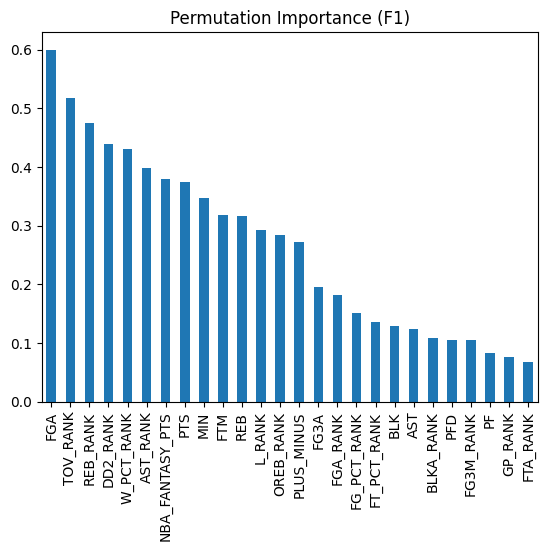

In [57]:
result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42, scoring='f1')
perm_importance = pd.Series(result.importances_mean, index=X.columns)
perm_importance = perm_importance[perm_importance > 0.01]  # Filter out low importance features
perm_importance.sort_values(ascending=False).plot(kind='bar', title='Permutation Importance (F1)')

The general results we have from each of the methods is:
- TEAM and PLAYER have no impact at all
- Various RANKs play a large part in predicting
- Games Played isn' too important (makes sense)

## Model Selection